In [1]:
import pandas as pd
import numpy as np

fs = pd.read_csv('../data/OASIS3_Freesurfer_output.csv')
cdr = pd.read_csv('../data/OASIS3_UDSb4_cdr.csv')
demo = pd.read_csv('../data/OASIS3_demographics.csv')

# Get follow-up duration per subject from CDR visits
cdr_sorted = cdr.sort_values(['OASISID', 'days_to_visit'])
followup = cdr_sorted.groupby('OASISID')['days_to_visit'].agg(
    first_visit='min',
    last_visit='max',
    n_visits='count'
).reset_index()
followup['followup_years'] = (followup['last_visit'] - followup['first_visit']) / 365.25

# Get trajectory
def get_trajectory(group):
    cdrs = group.sort_values('days_to_visit')['CDRTOT'].values
    if len(cdrs) < 2:
        return 'single_visit'
    first = cdrs[0]
    last = cdrs[-1]
    if first == 0 and last >= 1.0:
        return 'CN_to_AD'
    elif first == 0 and last == 0.5:
        return 'CN_to_MCI'
    elif first == 0 and last == 0:
        return 'stable_CN'
    elif first >= 1.0:
        return 'prevalent_AD'
    else:
        return 'other'

trajectories = cdr_sorted.groupby('OASISID').apply(get_trajectory).reset_index()
trajectories.columns = ['OASISID', 'trajectory']

# Merge with followup
cohort = trajectories.merge(followup, on='OASISID')

# Apply minimum followup threshold for stable CN - 3 years
# Converters are included regardless of followup length
stable_cn_qualified = cohort[
    (cohort['trajectory'] == 'stable_CN') & 
    (cohort['followup_years'] >= 3)
]
converters = cohort[cohort['trajectory'] == 'CN_to_AD']

print("Cohort assessment:")
print(f"Stable CN with ≥3 year followup: {len(stable_cn_qualified)}")
print(f"CN-to-AD converters: {len(converters)}")
print(f"\nConverter followup stats:")
print(converters['followup_years'].describe().round(2))
print(f"\nStable CN followup stats:")
print(stable_cn_qualified['followup_years'].describe().round(2))

Cohort assessment:
Stable CN with ≥3 year followup: 640
CN-to-AD converters: 75

Converter followup stats:
count    75.00
mean     11.76
std       6.00
min       2.02
25%       7.37
50%      11.56
75%      13.09
max      32.10
Name: followup_years, dtype: float64

Stable CN followup stats:
count    640.00
mean       8.84
std        4.77
min        3.01
25%        4.42
50%        8.11
75%       12.21
max       25.27
Name: followup_years, dtype: float64


/tmp/ipykernel_14073/2300131040.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trajectories = cdr_sorted.groupby('OASISID').apply(get_trajectory).reset_index()


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay, confusion_matrix
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

fs = pd.read_csv('../data/OASIS3_Freesurfer_output.csv')
cdr = pd.read_csv('../data/OASIS3_UDSb4_cdr.csv')
demo = pd.read_csv('../data/OASIS3_demographics.csv')

# Rebuild cohort
cdr_sorted = cdr.sort_values(['OASISID', 'days_to_visit'])

def get_trajectory(group):
    cdrs = group.sort_values('days_to_visit')['CDRTOT'].values
    if len(cdrs) < 2:
        return 'single_visit'
    first, last = cdrs[0], cdrs[-1]
    if first == 0 and last >= 1.0:
        return 'CN_to_AD'
    elif first == 0 and last == 0:
        return 'stable_CN'
    else:
        return 'other'

trajectories = cdr_sorted.groupby('OASISID', group_keys=False).apply(
    get_trajectory).reset_index()
trajectories.columns = ['OASISID', 'trajectory']

followup = cdr_sorted.groupby('OASISID')['days_to_visit'].agg(
    first_visit='min', last_visit='max').reset_index()
followup['followup_years'] = (followup['last_visit'] - followup['first_visit']) / 365.25

cohort = trajectories.merge(followup, on='OASISID')
stable_cn = cohort[(cohort['trajectory']=='stable_CN') & 
                    (cohort['followup_years']>=3)]
converters = cohort[cohort['trajectory']=='CN_to_AD']
final_cohort = pd.concat([stable_cn, converters])
final_cohort['label'] = (final_cohort['trajectory'] == 'CN_to_AD').astype(int)

# Get BASELINE FreeSurfer scan per subject (earliest scan)
fs_baseline = fs.sort_values('MR_session').groupby('Subject').first().reset_index()
fs_baseline = fs_baseline.rename(columns={'Subject': 'OASISID'})

# ICV corrections
fs_baseline['hippo_ICV'] = (fs_baseline['TOTAL_HIPPOCAMPUS_VOLUME'] / 
                              fs_baseline['IntraCranialVol']) * 100
fs_baseline['mean_entorhinal'] = (fs_baseline['lh_entorhinal_thickness'] + 
                                   fs_baseline['rh_entorhinal_thickness']) / 2
fs_baseline['mean_precuneus'] = (fs_baseline['lh_precuneus_thickness'] + 
                                  fs_baseline['rh_precuneus_thickness']) / 2
fs_baseline['amygdala_ICV'] = ((fs_baseline['Left-Amygdala_volume'] + 
                                  fs_baseline['Right-Amygdala_volume']) / 
                                 fs_baseline['IntraCranialVol']) * 100

# Merge
df = final_cohort.merge(fs_baseline[['OASISID', 'hippo_ICV', 'mean_entorhinal',
                                       'mean_precuneus', 'amygdala_ICV',
                                       'FS QC Status']], on='OASISID')
df = df.merge(demo[['OASISID', 'AgeatEntry', 'GENDER', 'EDUC', 'APOE']], on='OASISID')
df = df[df['FS QC Status'] == 'Passed']

# APOE4 carrier status
df['APOE4'] = df['APOE'].apply(lambda x: 1 if '4' in str(x) else 0)

features = ['hippo_ICV', 'mean_entorhinal', 'mean_precuneus', 
            'amygdala_ICV', 'AgeatEntry', 'GENDER', 'EDUC', 'APOE4']

X = df[features].dropna()
y = df.loc[X.index, 'label']

print("Final prediction cohort:", X.shape)
print("Class distribution:", y.value_counts().to_dict())
print(f"Converters: {y.sum()}, Stable CN: {(y==0).sum()}")
print(f"\nAPOE4 carriers in converters: {df.loc[X.index][y==1]['APOE4'].mean():.1%}")
print(f"APOE4 carriers in stable CN: {df.loc[X.index][y==0]['APOE4'].mean():.1%}")

Final prediction cohort: (542, 8)
Class distribution: {0: 498, 1: 44}
Converters: 44, Stable CN: 498

APOE4 carriers in converters: 45.5%
APOE4 carriers in stable CN: 31.7%


In [3]:
# Cross-validated model comparison with proper imbalance handling
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ratio = (y==0).sum() / (y==1).sum()

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', 
        random_state=42, min_samples_leaf=3),
    'XGBoost': XGBClassifier(
        scale_pos_weight=ratio, random_state=42, 
        verbosity=0, n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8)
}

print("5-Fold Cross-Validation (ROC-AUC):")
print("=" * 45)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

print("\n5-Fold Cross-Validation (Average Precision):")
print("=" * 45)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='average_precision')
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

5-Fold Cross-Validation (ROC-AUC):
Logistic Regression: 0.834 ± 0.033
Random Forest: 0.785 ± 0.076
XGBoost: 0.714 ± 0.083

5-Fold Cross-Validation (Average Precision):
Logistic Regression: 0.414 ± 0.091
Random Forest: 0.395 ± 0.126
XGBoost: 0.319 ± 0.112


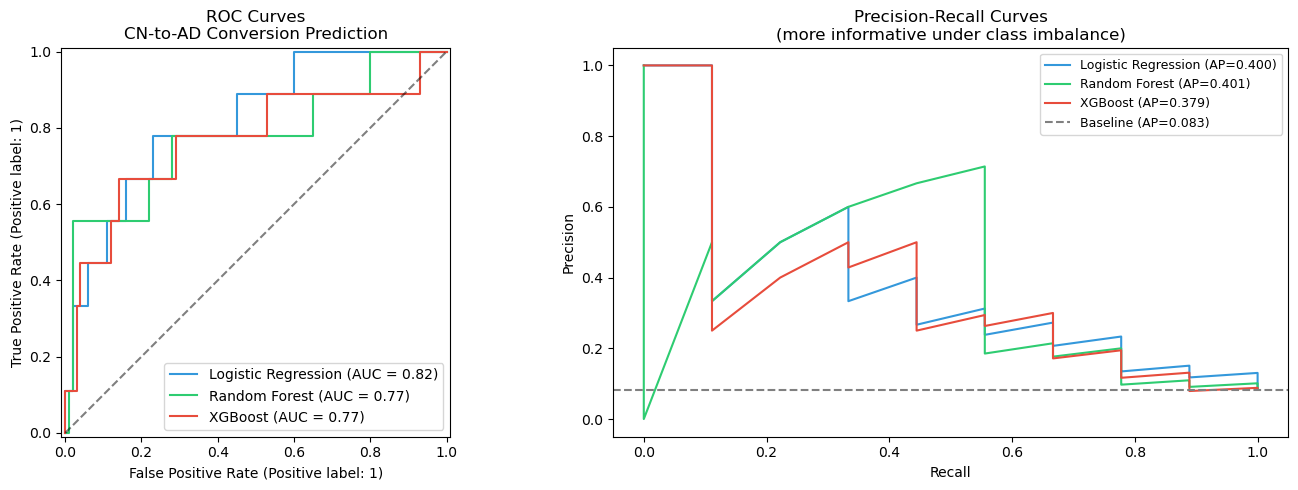

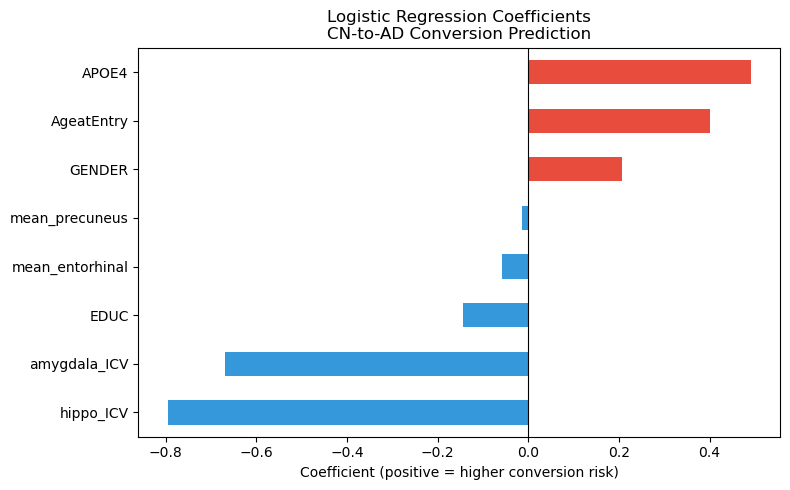

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_colors = {
    'Logistic Regression': '#3498db',
    'Random Forest': '#2ecc71', 
    'XGBoost': '#e74c3c'
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:,1]
    
    # ROC
    RocCurveDisplay.from_predictions(
        y_test, y_proba, ax=axes[0], name=name,
        color=model_colors[name])
    
    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, 
                color=model_colors[name],
                label=f'{name} (AP={ap:.3f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0].set_title('ROC Curves\nCN-to-AD Conversion Prediction')

# Baseline for PR curve
baseline = y_test.sum() / len(y_test)
axes[1].axhline(y=baseline, color='gray', linestyle='--', 
                label=f'Baseline (AP={baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves\n(more informative under class imbalance)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../results/05_conversion_prediction_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance from LR coefficients
lr_model = models['Logistic Regression'].fit(X_train, y_train)
coefs = pd.Series(
    lr_model.named_steps['clf'].coef_[0],
    index=features).sort_values()

fig2, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#e74c3c' if c > 0 else '#3498db' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\nCN-to-AD Conversion Prediction')
ax.set_xlabel('Coefficient (positive = higher conversion risk)')
plt.tight_layout()
plt.savefig('../results/05_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

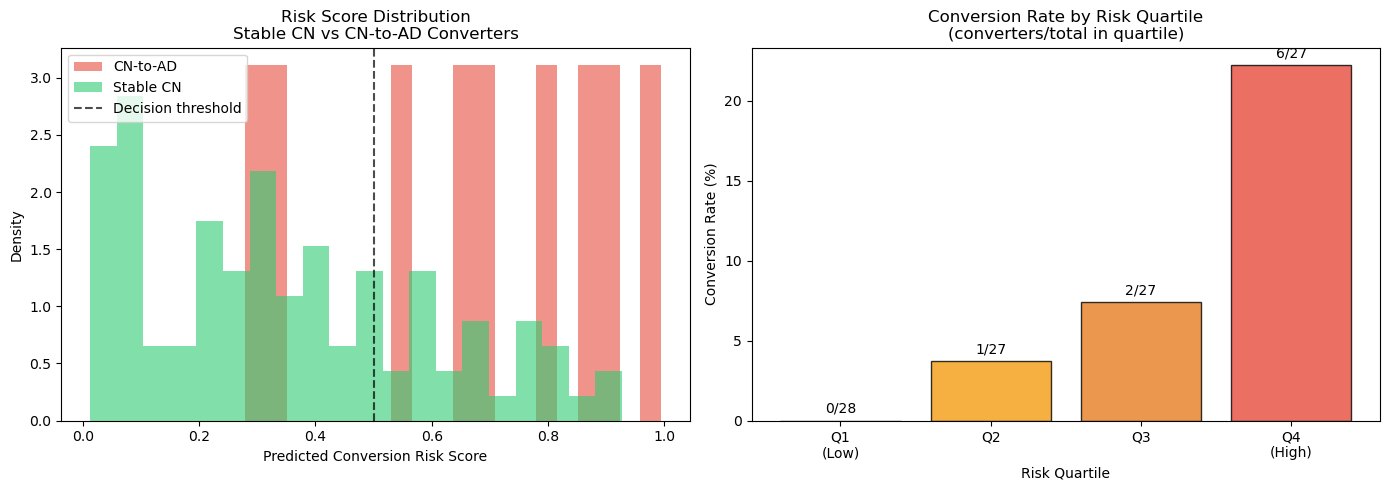

Conversion rates by quartile:
  risk_quartile  sum  count  conversion_rate
0     Q1\n(Low)    0     28              0.0
1            Q2    1     27              3.7
2            Q3    2     27              7.4
3    Q4\n(High)    6     27             22.2


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Rebuild data
fs = pd.read_csv('../data/OASIS3_Freesurfer_output.csv')
cdr = pd.read_csv('../data/OASIS3_UDSb4_cdr.csv')
demo = pd.read_csv('../data/OASIS3_demographics.csv')

cdr_sorted = cdr.sort_values(['OASISID', 'days_to_visit'])

def get_trajectory(group):
    cdrs = group.sort_values('days_to_visit')['CDRTOT'].values
    if len(cdrs) < 2:
        return 'single_visit'
    first, last = cdrs[0], cdrs[-1]
    if first == 0 and last >= 1.0:
        return 'CN_to_AD'
    elif first == 0 and last == 0:
        return 'stable_CN'
    else:
        return 'other'

trajectories = cdr_sorted.groupby('OASISID', group_keys=False).apply(
    get_trajectory).reset_index()
trajectories.columns = ['OASISID', 'trajectory']

followup = cdr_sorted.groupby('OASISID')['days_to_visit'].agg(
    first_visit='min', last_visit='max').reset_index()
followup['followup_years'] = (followup['last_visit'] - followup['first_visit']) / 365.25

cohort = trajectories.merge(followup, on='OASISID')
stable_cn = cohort[(cohort['trajectory']=='stable_CN') & (cohort['followup_years']>=3)]
converters = cohort[cohort['trajectory']=='CN_to_AD']
final_cohort = pd.concat([stable_cn, converters])
final_cohort['label'] = (final_cohort['trajectory'] == 'CN_to_AD').astype(int)

fs_baseline = fs.sort_values('MR_session').groupby('Subject').first().reset_index()
fs_baseline = fs_baseline.rename(columns={'Subject': 'OASISID'})
fs_baseline['hippo_ICV'] = (fs_baseline['TOTAL_HIPPOCAMPUS_VOLUME'] / 
                              fs_baseline['IntraCranialVol']) * 100
fs_baseline['mean_entorhinal'] = (fs_baseline['lh_entorhinal_thickness'] + 
                                   fs_baseline['rh_entorhinal_thickness']) / 2
fs_baseline['mean_precuneus'] = (fs_baseline['lh_precuneus_thickness'] + 
                                  fs_baseline['rh_precuneus_thickness']) / 2
fs_baseline['amygdala_ICV'] = ((fs_baseline['Left-Amygdala_volume'] + 
                                  fs_baseline['Right-Amygdala_volume']) / 
                                 fs_baseline['IntraCranialVol']) * 100

df = final_cohort.merge(fs_baseline[['OASISID', 'hippo_ICV', 'mean_entorhinal',
                                       'mean_precuneus', 'amygdala_ICV',
                                       'FS QC Status']], on='OASISID')
df = df.merge(demo[['OASISID', 'AgeatEntry', 'GENDER', 'EDUC', 'APOE']], on='OASISID')
df = df[df['FS QC Status'] == 'Passed']
df['APOE4'] = df['APOE'].apply(lambda x: 1 if '4' in str(x) else 0)

features = ['hippo_ICV', 'mean_entorhinal', 'mean_precuneus',
            'amygdala_ICV', 'AgeatEntry', 'GENDER', 'EDUC', 'APOE4']

X = df[features].dropna()
y = df.loc[X.index, 'label']

ratio = (y==0).sum() / (y==1).sum()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, min_samples_leaf=3),
    'XGBoost': XGBClassifier(
        scale_pos_weight=ratio, random_state=42,
        verbosity=0, n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8)
}

# Fit all models
for name, model in models.items():
    model.fit(X_train, y_train)

# Now risk stratification
best_model = models['Logistic Regression']

df_test = X_test.copy()
df_test['conversion_risk'] = best_model.predict_proba(X_test)[:,1]
df_test['true_label'] = y_test.values
df_test['diagnosis'] = df_test['true_label'].map({0: 'Stable CN', 1: 'CN-to-AD'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, group in df_test.groupby('diagnosis'):
    color = '#e74c3c' if label == 'CN-to-AD' else '#2ecc71'
    ax.hist(group['conversion_risk'].to_numpy(), bins=20, alpha=0.6,
            color=color, label=label, density=True)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.7, label='Decision threshold')
ax.set_xlabel('Predicted Conversion Risk Score')
ax.set_ylabel('Density')
ax.set_title('Risk Score Distribution\nStable CN vs CN-to-AD Converters')
ax.legend()

ax2 = axes[1]
df_test['risk_quartile'] = pd.qcut(df_test['conversion_risk'],
                                    q=4, labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4\n(High)'])
conversion_by_quartile = df_test.groupby('risk_quartile')['true_label'].agg(
    ['sum', 'count']).reset_index()
conversion_by_quartile['conversion_rate'] = (conversion_by_quartile['sum'] /
                                               conversion_by_quartile['count'] * 100)

bars = ax2.bar(conversion_by_quartile['risk_quartile'].astype(str),
               conversion_by_quartile['conversion_rate'],
               color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'],
               alpha=0.8, edgecolor='black')

for bar, (_, row) in zip(bars, conversion_by_quartile.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row['sum']:.0f}/{row['count']:.0f}",
            ha='center', fontsize=10)

ax2.set_xlabel('Risk Quartile')
ax2.set_ylabel('Conversion Rate (%)')
ax2.set_title('Conversion Rate by Risk Quartile\n(converters/total in quartile)')

plt.tight_layout()
plt.savefig('../results/05_risk_stratification.png', dpi=150, bbox_inches='tight')
plt.show()

print("Conversion rates by quartile:")
print(conversion_by_quartile[['risk_quartile', 'sum', 'count', 'conversion_rate']].round(1))

## Results: CN-to-AD Conversion Prediction

Logistic regression achieves AUC=0.82 and average precision=0.40 (vs baseline 
0.083) for predicting conversion from cognitively normal to Alzheimer's disease 
using baseline structural MRI and demographic features (n=542, 44 converters).

Risk stratification reveals strong monotonic enrichment: subjects in the highest 
risk quartile convert at 22.2% (6/27), compared to 0% in the lowest quartile. 
This 2.7x enrichment over the population base rate (8.3%) suggests clinical 
utility for identifying high-risk individuals for targeted monitoring or 
preventive intervention.

APOE4 carrier status and age at entry are the strongest predictors of conversion, 
consistent with established genetic and epidemiological risk factors. Hippocampal 
and amygdala volume provide complementary structural biomarker signal, while 
education shows a protective effect consistent with the cognitive reserve hypothesis.

**Limitations:** Small converter cohort (n=44 in test-eligible subjects) limits 
statistical power. External validation on an independent cohort is required before 
clinical translation.